<a href="https://colab.research.google.com/github/wahyuwinanta/WeldingApp/blob/main/notebooks/yolov8n-instance-segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed May 13 12:05:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 141.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 244.3 MB/s eta 0:00:00


In [3]:
import os
import shutil
import random
import glob
import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, Image


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
HOME = os.getcwd() # Define HOME here to ensure it's available

In [5]:
# Download Dataset dari Roboflow (Pastikan ganti API Key & Project Anda)
from roboflow import Roboflow
rf = Roboflow(api_key="YvnVogcaoID0j5yIz1sU")
project = rf.workspace("skripsi-0vmgq").project("cacatpengelasan")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CacatPengelasan-1 in yolov8:: 100%|██████████| 3603/3603 [00:00<00:00, 18765.14it/s]


In [6]:
print("\n=== INFORMASI DATASET ROBOLOFLOW ===")
train_img_path = os.path.join(dataset.location, "train", "images")
train_label_path = os.path.join(dataset.location, "train", "labels")

if os.path.exists(train_img_path):
    num_images = len(glob.glob(os.path.join(train_img_path, "*.jpg")))
    num_labels = len(glob.glob(os.path.join(train_label_path, "*.txt")))
    print(f"Lokasi Dataset : {dataset.location}")
    print(f"Jumlah Gambar  : {num_images}")
    print(f"Jumlah Label   : {num_labels}")
else:
    print("Folder training tidak ditemukan!")


=== INFORMASI DATASET ROBOLOFLOW ===
Lokasi Dataset : /content/CacatPengelasan-1
Jumlah Gambar  : 1800
Jumlah Label   : 1800


In [7]:
# 3. Load Nama Kelas dari data.yaml
with open(os.path.join(dataset.location, "data.yaml"), 'r') as f:
    data_conf = yaml.safe_load(f)
    class_names = data_conf['names']

print(f"Daftar Kelas   : {class_names}")

Daftar Kelas   : ['Excess', 'Good Welding', 'Undercut']


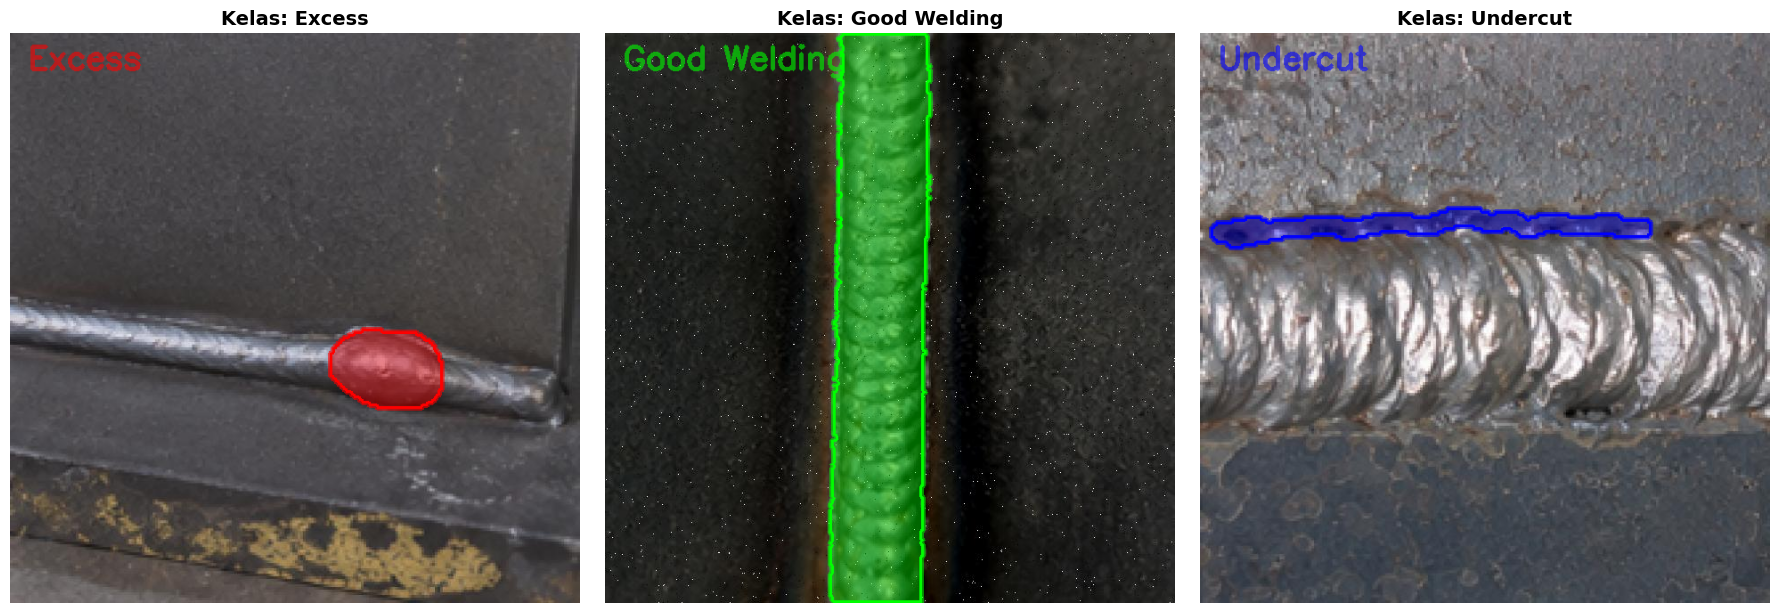

In [8]:
def plot_samples_per_class(img_dir, label_dir, class_names):
    # Setup warna unik untuk 3 kelas Anda
    # Excess (Merah), Good Welding (Hijau), Undercut (Biru)
    class_colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]

    # Mencari satu gambar contoh untuk setiap ID kelas
    samples_to_show = {} # {class_id: img_path}

    all_label_files = glob.glob(os.path.join(label_dir, "*.txt"))

    for label_path in all_label_files:
        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                class_id = int(first_line.split()[0])
                if class_id not in samples_to_show:
                    img_path = label_path.replace("labels", "images").replace(".txt", ".jpg")
                    if os.path.exists(img_path):
                        samples_to_show[class_id] = img_path

        # Berhenti jika semua kelas sudah punya contoh
        if len(samples_to_show) == len(class_names):
            break

    # Mulai Plotting
    num_classes = len(class_names)
    plt.figure(figsize=(18, 6))

    for i, class_id in enumerate(sorted(samples_to_show.keys())):
        img_path = samples_to_show[class_id]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        overlay = img.copy()
        h, w, _ = img.shape

        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")

        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                current_class_id = int(parts[0])

                # Hanya gambar anotasinya jika class_id sesuai dengan target kolom
                if current_class_id == class_id:
                    color = class_colors[class_id % len(class_colors)]
                    coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)
                    coords[:, 0] *= w
                    coords[:, 1] *= h
                    pts = coords.astype(np.int32).reshape((-1, 1, 2))

                    cv2.fillPoly(overlay, [pts], color)
                    cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)

                    cv2.putText(img, class_names[class_id], (20, 40),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

        # Efek Transparansi
        alpha = 0.4
        img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

        plt.subplot(1, num_classes, i + 1)
        plt.imshow(img)
        plt.title(f"Kelas: {class_names[class_id]}", fontsize=14, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Panggil fungsi dengan daftar kelas Anda
class_names = ['Excess', 'Good Welding', 'Undercut']
plot_samples_per_class(train_img_path, train_label_path, class_names)

In [9]:
# Fungsi Splitting Dataset
def split_dataset(source_path, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    # Path folder tujuan
    base_dir = os.path.join(HOME, 'split_dataset')
    for split in ['train', 'valid', 'test']:
        for sub in ['images', 'labels']:
            os.makedirs(os.path.join(base_dir, split, sub), exist_ok=True)

    # Ambil semua file gambar dari folder train bawaan Roboflow
    image_files = glob.glob(os.path.join(source_path, 'train/images/*.jpg'))
    random.shuffle(image_files)

    total = len(image_files)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits = {
        'train': image_files[:train_end],
        'valid': image_files[train_end:val_end],
        'test': image_files[val_end:]
    }

    for split_name, files in splits.items():
        for img_path in files:
            # Pindahkan Gambar
            fname = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(base_dir, split_name, 'images', fname))

            # Pindahkan Label (TXT) yang bersesuaian
            label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
            if os.path.exists(label_path):
                shutil.copy(label_path, os.path.join(base_dir, split_name, 'labels', fname.replace('.jpg', '.txt')))

    return base_dir

# Eksekusi splitting
new_dataset_path = split_dataset(dataset.location)

In [10]:
# Update file data.yaml agar mengarah ke folder baru

with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['train'] = os.path.join(new_dataset_path, 'train/images')
data_yaml['val'] = os.path.join(new_dataset_path, 'valid/images')
data_yaml['test'] = os.path.join(new_dataset_path, 'test/images')

with open(f"{new_dataset_path}/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

print(f"Dataset berhasil dibagi! Lokasi: {new_dataset_path}")

Dataset berhasil dibagi! Lokasi: /content/split_dataset


In [11]:
print("=== JUMLAH GAMBAR PER DATASET SPLIT ===")

# List folder yang akan dihitung
splits = ['train', 'valid', 'test']
total_images_all = 0

for split in splits:
    # Path menuju folder images masing-masing split
    img_path = os.path.join(new_dataset_path, split, 'images')

    if os.path.exists(img_path):
        # Menghitung file dengan ekstensi .jpg
        num_images = len(glob.glob(os.path.join(img_path, '*.jpg')))
        total_images_all += num_images

        # Menghitung persentase untuk validasi rasio
        percentage = (num_images / 1800) * 100 # Berdasarkan total awal 1800

        print(f"--- {split.capitalize()} Set ---")
        print(f"  Jumlah Gambar : {num_images} file ({percentage:.1f}%)")
    else:
        print(f"--- {split.capitalize()} Set ---")
        print(f"  Folder tidak ditemukan!")

print("\n------------------------------")
print(f"TOTAL SELURUH GAMBAR : {total_images_all} file")

=== JUMLAH GAMBAR PER DATASET SPLIT ===
--- Train Set ---
  Jumlah Gambar : 1260 file (70.0%)
--- Valid Set ---
  Jumlah Gambar : 360 file (20.0%)
--- Test Set ---
  Jumlah Gambar : 180 file (10.0%)

------------------------------
TOTAL SELURUH GAMBAR : 1800 file


In [12]:
# Inisialisasi model pre-trained
model = YOLO('yolov8n-seg.pt')

# Mulai Training
results = model.train(
    data=f"{new_dataset_path}/data.yaml",
    epochs=100,
    imgsz=640,
    device=0,
    name='yolov8_custom_seg',
    patience=20,
    exist_ok=True
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/split_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_custom_seg, nbs=64, nms=False, opset=None, optimize=Fal

In [13]:
# Mengambil hasil validasi
metrics = model.val()

# Menghitung Kecepatan (Inference Time & FPS)
# YOLOv8 menyimpan waktu dalam ms: [preprocess, inference, loss, postprocess]
t_preprocess = metrics.speed['preprocess']
t_inference = metrics.speed['inference']
t_postprocess = metrics.speed['postprocess']
total_time_ms = t_preprocess + t_inference + t_postprocess
fps = 1000 / total_time_ms

# Membuat Tabel Ringkasan untuk Laporan Skripsi
summary_data = {
    "Matriks Evaluasi": ["mAP@50 (B)", "mAP@50-95 (B)", "mAP@50 (M)", "mAP@50-95 (M)",
                         "Precision", "Recall", "Inference Time", "Kecepatan (FPS)"],
    "Nilai": [
        f"{metrics.box.map50:.4f}",
        f"{metrics.box.map:.4f}",
        f"{metrics.seg.map50:.4f}",
        f"{metrics.seg.map:.4f}",
        f"{metrics.box.mp:.4f}",
        f"{metrics.box.mr:.4f}",
        f"{total_time_ms:.2f} ms/img",
        f"{fps:.2f} FPS"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n=== TABEL EVALUASI MODEL UNTUK SKRIPSI ===")
display(df_summary)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5994.7±2198.4 MB/s, size: 70.8 KB)
val: Scanning /content/split_dataset/valid/labels.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 215.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 17.8it/s 1.3s
                   all        360        361       0.85      0.781      0.808      0.623      0.842      0.776      0.796      0.581
                Excess        125        125      0.962      0.968      0.991      0.706      0.962      0.968      0.991      0.692
          Good Welding        108        109       0.98      0.982      0.995      0.907       0.98      0.982      0.995      0.901

,Matriks Evaluasi,Nilai
0,mAP@50 (B),0.8076
1,mAP@50-95 (B),0.6226
2,mAP@50 (M),0.7963
3,mAP@50-95 (M),0.5810
4,Precision,0.8498
5,Recall,0.7811
6,Inference Time,1.63 ms/img
7,Kecepatan (FPS),611.99 FPS


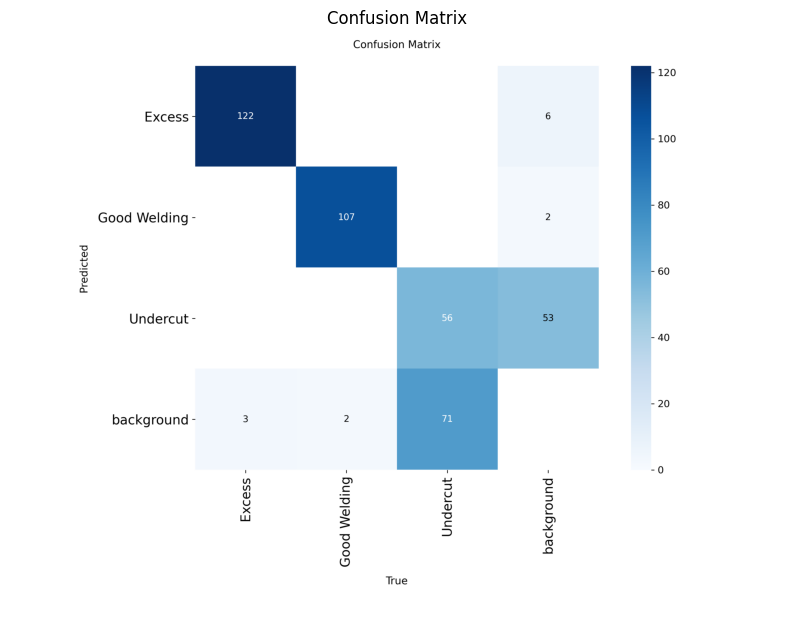

Grafik F1_curve.png tidak ditemukan.


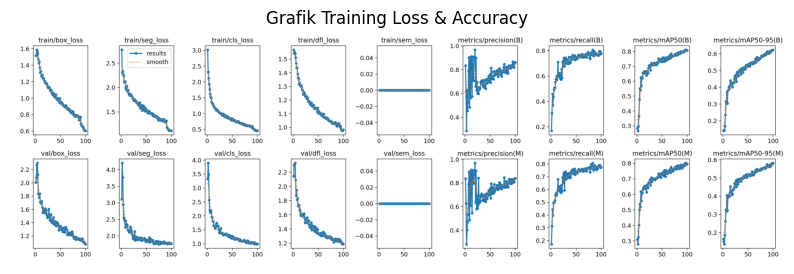

Grafik PR_curve.png tidak ditemukan.


In [14]:
# Path folder hasil training
RESULT_DIR = f"{HOME}/runs/segment/yolov8_custom_seg"

def show_results(image_name, title):
    img_path = os.path.join(RESULT_DIR, image_name)
    if os.path.exists(img_path):
        plt.figure(figsize=(10, 8))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
        plt.show()
    else:
        print(f"Grafik {image_name} tidak ditemukan.")

# Menampilkan grafik evaluasi utama
show_results("confusion_matrix.png", "Confusion Matrix")
show_results("F1_curve.png", "F1-Score Curve")
show_results("results.png", "Grafik Training Loss & Accuracy") # Berisi Box Loss, Class Loss, DFL
show_results("PR_curve.png", "Precision-Recall Curve")

In [15]:
# Membaca file results.csv yang dihasilkan saat training
results_csv_path = os.path.join(RESULT_DIR, 'results.csv')

if os.path.exists(results_csv_path):
    results_df = pd.read_csv(results_csv_path)
    results_df.columns = results_df.columns.str.strip() # Bersihkan spasi pada nama kolom

    # Ambil baris terakhir (hasil akhir training)
    last_loss = results_df.iloc[-1]

    print("\n=== DETAIL LOSS FUNCTION (FINAL EPOCH) ===")
    print(f"Train Box Loss  : {last_loss['train/box_loss']:.4f}")
    print(f"Train Class Loss: {last_loss['train/cls_loss']:.4f}")
    print(f"Train DFL Loss  : {last_loss['train/dfl_loss']:.4f}")
    print("-" * 40)
    print(f"Val Box Loss    : {last_loss['val/box_loss']:.4f}")
    print(f"Val Class Loss  : {last_loss['val/cls_loss']:.4f}")
    print(f"Val DFL Loss    : {last_loss['val/dfl_loss']:.4f}")


=== DETAIL LOSS FUNCTION (FINAL EPOCH) ===
Train Box Loss  : 0.6040
Train Class Loss: 0.4573
Train DFL Loss  : 0.9838
----------------------------------------
Val Box Loss    : 1.0777
Val Class Loss  : 0.9926
Val DFL Loss    : 1.1864


Model berhasil dimuat!
Menjalankan tes pada 3 sampel gambar...

0: 640x640 2 Excesss, 6.9ms
1: 640x640 1 Good Welding, 6.9ms
2: 640x640 1 Undercut, 6.9ms
Speed: 0.5ms preprocess, 6.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/final_test_results

=== HASIL VISUALISASI TES ===


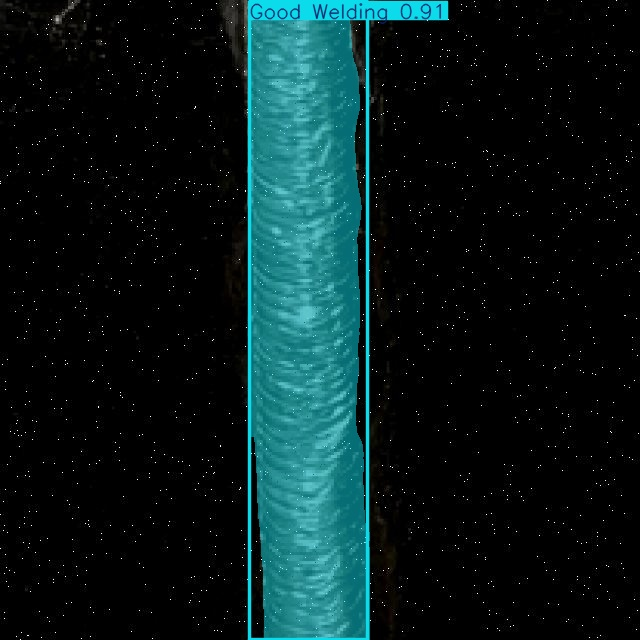

File: image1.jpg



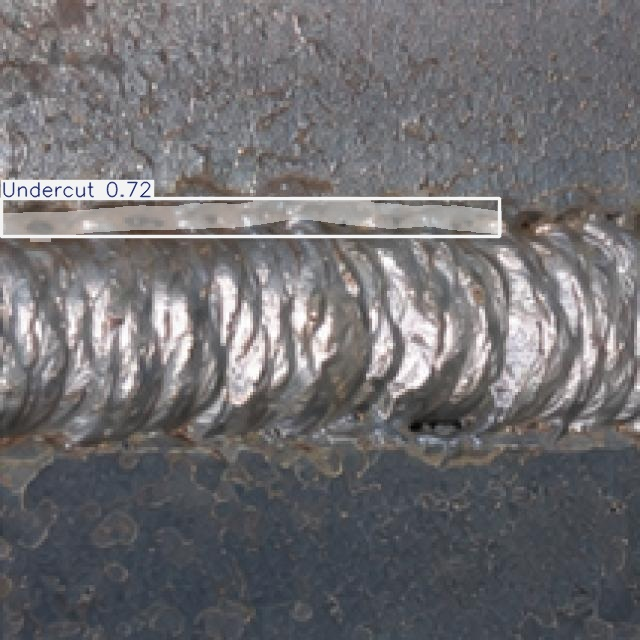

File: image2.jpg



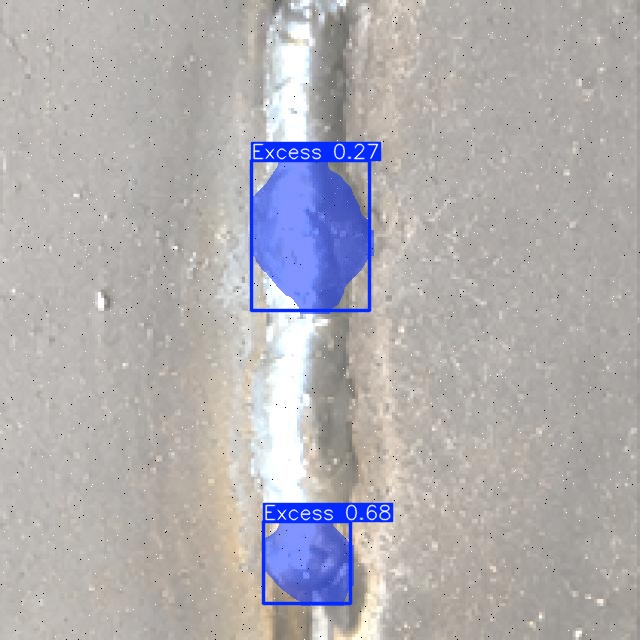

File: image0.jpg

--- Analisis Data Gambar Pertama ---
Jumlah Objek Terdeteksi: 2
Status Segmentasi: Sukses (Masks ditemukan)
 - Kelas: Excess (Conf: 0.68)
 - Kelas: Excess (Conf: 0.27)


In [16]:
# Load Model Terbaik (Hasil Training)
# Pastikan path ini sesuai dengan lokasi file best.pt Anda
HOME = os.getcwd()
model_path = f"{HOME}/runs/segment/yolov8_custom_seg/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)
    print("Model berhasil dimuat!")
else:
    print("Model tidak ditemukan! Periksa kembali path file best.pt Anda.")

# Menentukan Sumber Data Uji (Test Set)
# Kita gunakan folder 'test' yang dibuat saat proses splitting sebelumnya
test_images_path = f"{HOME}/split_dataset/test/images"
test_image_list = glob.glob(os.path.join(test_images_path, "*.jpg"))

if not test_image_list:
    print("Data uji tidak ditemukan di folder split_dataset/test/images")
else:
    # Menjalankan Prediksi (Inference)
    # Kita ambil 3 sampel acak untuk divisualisasikan
    samples = random.sample(test_image_list, min(3, len(test_image_list)))

    print(f"Menjalankan tes pada {len(samples)} sampel gambar...")

    # Jalankan prediksi
    results = model.predict(
        source=samples,
        conf=0.25,        # Ambang batas kepercayaan (bisa disesuaikan)
        save=True,        # Simpan hasil visualisasi
        line_width=2,     # Ketebalan garis box
        name="final_test_results",
        exist_ok=True
    )

    # Menampilkan Hasil Visualisasi
    print("\n=== HASIL VISUALISASI TES ===")
    prediction_dir = f"{HOME}/runs/segment/final_test_results"

    for res_img in glob.glob(os.path.join(prediction_dir, "*.jpg")):
        display(Image(filename=res_img, width=600))
        print(f"File: {os.path.basename(res_img)}\n")

# Ekstraksi Data Prediksi (Opsional - Untuk Analisis Tabel)
# Contoh mengambil koordinat mask dan box dari gambar pertama
if 'results' in locals():
    first_res = results[0]
    print("--- Analisis Data Gambar Pertama ---")
    print(f"Jumlah Objek Terdeteksi: {len(first_res.boxes)}")
    if first_res.masks is not None:
        print(f"Status Segmentasi: Sukses (Masks ditemukan)")
        # Menampilkan class ID yang terdeteksi
        for box in first_res.boxes:
            class_id = int(box.cls[0])
            conf = float(box.conf[0])
            print(f" - Kelas: {model.names[class_id]} (Conf: {conf:.2f})")

In [18]:
# Load Model
model_path = f"{os.getcwd()}/runs/segment/yolov8_custom_seg/weights/best.pt"
model = YOLO(model_path)

# Jalankan Prediksi pada satu gambar
# Ganti path_gambar dengan lokasi gambar yang ingin diuji
path_gambar = "path/ke/gambar/anda.jpg"
results = model.predict(source=/content/split_dataset/test/images/excess_weld-104-_png.rf.bc11c5637a557a8ad90c2c0c0386b207.jpg, conf=0.25, save=False)

res = results[0]

# Proses Ekstraksi Piksel
if res.masks is not None:
    # Ambil gambar asli
    img = res.orig_img

    # Buat kanvas hitam dengan ukuran yang sama dengan gambar asli
    final_mask = np.zeros(img.shape[:2], dtype=np.uint8)

    # Gabungkan semua masker jika ada lebih dari satu objek terdeteksi
    for mask in res.masks.data:
        # Resize masker ke ukuran asli gambar
        m = mask.cpu().numpy()
        m = cv2.resize(m, (img.shape[1], img.shape[0]))
        final_mask = np.maximum(final_mask, m)

    # Ubah masker menjadi format biner (0 atau 255)
    final_mask = (final_mask > 0).astype(np.uint8) * 255

    # Gunakan operasi Bitwise AND untuk mengambil piksel asli berdasarkan masker
    # Piksel di luar masker akan otomatis menjadi hitam (0)
    segmented_img = cv2.bitwise_and(img, img, mask=final_mask)

    # Tampilkan Hasil
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Gambar Asli")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Hasil Segmentasi (Hanya Objek)")
    plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

    # Simpan hasil jika diperlukan
    # cv2.imwrite("hasil_ekstraksi.png", segmented_img)
else:
    print("Tidak ada objek yang terdeteksi untuk disegmentasi.")

SyntaxError: invalid syntax (3562366473.py, line 8)

In [ ]:
# Ekspor ke TFLite (Float16 untuk optimasi speed & size)
export_path = model.export(format="tflite", half=True)

print(f"--- PROSES SELESAI ---")
print(f"Model terbaik tersimpan di: {HOME}/runs/segment/yolov8_custom_seg/weights/best.pt")
print(f"Model TFLite tersimpan di: {export_path}")